# CS/TVM Asymmetric Parameter Fit


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import root, root_scalar

pd.set_option("display.precision", 6)

g = 2.0
mp = mn = 0.938
rho0 = 1.23e-3  # GeV^3
GEV_TO_MEV = 1000.0
GEV3_TO_FM3 = (1.0 / 0.1973269804) ** 3

# These targets reproduce the cs/tvm numbers already used in the asymmetric notebooks.

TARGET_S0 = 32.5  # MeV
TARGET_L0 = 58.9  # MeV

# Published / currently used parameter sets for validation.
published_parameters = {
    "cs": {
        "eq": {"an": 36.93, "bn": 579.17, "apn": 53.60, "bpn": 579.17},
        "neq": {"an": 26.535, "bn": 383.788, "apn": 63.999, "bpn": 774.64},
    },
    "tvm": {
        "eq": {"an": 37.33, "bn": 560.08, "apn": 53.72, "bpn": 560.08},
        "neq": {"an": 26.78, "bn": 363.72, "apn": 64.67, "bpn": 756.4},
    },
}

# Use the symmetric averages from the published branches as the baseline.
symmetric_baselines = {
    model: {
        "a_bar": 0.5 * (branches["eq"]["an"] + branches["eq"]["apn"]),
        "b_bar": 0.5 * (branches["eq"]["bn"] + branches["eq"]["bpn"]),
    }
    for model, branches in published_parameters.items()
}

pd.DataFrame(symmetric_baselines).T


,a_bar,b_bar
cs,45.265,579.17
tvm,45.525,560.08


## Model definitions

For each branch we write

- `a_n = a_bar - delta_a`
- `a_pn = a_bar + delta_a`
- `b_n = b_bar - delta_b`
- `b_pn = b_bar + delta_b`

The `eq` branch corresponds to `delta_b = 0`.


In [3]:
def kf_from_nid(n_id):
    return (6.0 * np.pi**2 * n_id / g) ** (1.0 / 3.0)


def eps_id_fermion(mass, kf):
    ef = np.sqrt(kf * kf + mass * mass)
    return g / (16.0 * np.pi**2) * (
        kf * ef * (2.0 * kf * kf + mass * mass)
        - mass**4 * np.log((kf + ef) / mass)
    )


def f_cs(x):
    x = np.asarray(x)
    out = np.exp(-(3.0 * x) / (4.0 - x) - (4.0 * x) / (4.0 - x) ** 2)
    out = np.where(x < 4.0, out, np.nan)
    return out if out.ndim else float(out)


def f_tvm(x):
    return np.exp(-x - 0.5 * x * x)


VOLUME_FRACTION = {
    "cs": f_cs,
    "tvm": f_tvm,
}


def branch_parameters(a_bar, b_bar, delta_a, delta_b):
    return {
        "an": a_bar - delta_a,
        "apn": a_bar + delta_a,
        "bn": b_bar - delta_b,
        "bpn": b_bar + delta_b,
    }


def energy_per_baryon_hadronic(n_b, y, *, model, an, bn, apn, bpn):
    n_p = n_b * y
    n_n = n_b * (1.0 - y)

    x_p = bn * n_p + bpn * n_n
    x_n = bpn * n_p + bn * n_n

    f_model = VOLUME_FRACTION[model]
    f_p = f_model(x_p)
    f_n = f_model(x_n)

    if (not np.isfinite(f_p)) or (not np.isfinite(f_n)) or f_p <= 0.0 or f_n <= 0.0:
        return np.nan

    kfp = kf_from_nid(n_p / f_p) if n_p > 0.0 else 0.0
    kfn = kf_from_nid(n_n / f_n) if n_n > 0.0 else 0.0

    eps = (
        f_p * eps_id_fermion(mp, kfp)
        + f_n * eps_id_fermion(mn, kfn)
        - an * (n_p**2 + n_n**2)
        - 2.0 * apn * n_p * n_n
    )
    return eps / n_b


def symmetry_curves(model, params, density_grid):
    e_snm = []
    e_pnm = []
    for n_b in density_grid:
        e_snm.append((energy_per_baryon_hadronic(n_b, 0.5, model=model, **params) - mp) * GEV_TO_MEV)
        e_pnm.append((energy_per_baryon_hadronic(n_b, 0.0, model=model, **params) - mp) * GEV_TO_MEV)

    e_snm = np.asarray(e_snm)
    e_pnm = np.asarray(e_pnm)
    s_vals = e_pnm - e_snm
    n_fm = density_grid * GEV3_TO_FM3
    l_vals = 3.0 * n_fm * np.gradient(s_vals, n_fm)
    return s_vals, l_vals


def s0_l0(model, a_bar, b_bar, delta_a, delta_b, density_grid):
    params = branch_parameters(a_bar, b_bar, delta_a, delta_b)
    s_vals, l_vals = symmetry_curves(model, params, density_grid)
    idx = np.argmin(np.abs(density_grid - rho0))
    return float(s_vals[idx]), float(l_vals[idx]), params


density_grid = np.linspace(0.75, 1.25, 51) * rho0


In [4]:
def fit_eq_branch(model, a_bar, b_bar, density_grid, target_s0=TARGET_S0):
    def objective(delta_a):
        s0, _, _ = s0_l0(model, a_bar, b_bar, delta_a, 0.0, density_grid)
        return s0 - target_s0

    sol = root_scalar(objective, bracket=(-30.0, 30.0), method="brentq")
    s0, l0, params = s0_l0(model, a_bar, b_bar, sol.root, 0.0, density_grid)
    return {
        "model": model,
        "branch": "eq",
        "delta_a": sol.root,
        "delta_b": 0.0,
        "S0": s0,
        "L0": l0,
        **params,
    }


def fit_neq_branch(model, a_bar, b_bar, density_grid, target_s0=TARGET_S0, target_l0=TARGET_L0):
    def objective(x):
        delta_a, delta_b = x
        s0, l0, _ = s0_l0(model, a_bar, b_bar, delta_a, delta_b, density_grid)
        return np.array([s0 - target_s0, l0 - target_l0])

    initial_guess = np.array([18.0, 190.0])
    sol = root(objective, x0=initial_guess, method="hybr")
    if not sol.success:
        raise RuntimeError(f"Root solve failed for {model}: {sol.message}")

    delta_a, delta_b = sol.x
    s0, l0, params = s0_l0(model, a_bar, b_bar, delta_a, delta_b, density_grid)
    return {
        "model": model,
        "branch": "neq",
        "delta_a": delta_a,
        "delta_b": delta_b,
        "S0": s0,
        "L0": l0,
        **params,
    }


fit_rows = []
for model, base in symmetric_baselines.items():
    fit_rows.append(fit_eq_branch(model, base["a_bar"], base["b_bar"], density_grid))
    fit_rows.append(fit_neq_branch(model, base["a_bar"], base["b_bar"], density_grid))

fit_df = pd.DataFrame(fit_rows)
fit_df[["model", "branch", "an", "bn", "apn", "bpn", "S0", "L0"]]


,model,branch,an,bn,apn,bpn,S0,L0
0,cs,eq,37.110193,579.170000,53.419807,579.170000,32.5,121.910973
1,cs,neq,26.743127,386.576614,63.786873,771.763386,32.5,58.900000
2,tvm,eq,37.514082,560.080000,53.535918,560.080000,32.5,121.833999
3,tvm,neq,26.587834,366.270354,64.462166,753.889646,32.5,58.900000


In [5]:
published_rows = []
for model, branches in published_parameters.items():
    for branch, params in branches.items():
        s0, l0, _ = s0_l0(
            model,
            0.5 * (params["an"] + params["apn"]),
            0.5 * (params["bn"] + params["bpn"]),
            0.5 * (params["apn"] - params["an"]),
            0.5 * (params["bpn"] - params["bn"]),
            density_grid,
        )
        published_rows.append({"model": model, "branch": branch, "published_S0": s0, "published_L0": l0, **params})

published_df = pd.DataFrame(published_rows)

comparison = fit_df.merge(
    published_df,
    on=["model", "branch"],
    suffixes=("_fit", "_pub"),
)

for key in ["an", "bn", "apn", "bpn"]:
    comparison[f"d_{key}"] = comparison[f"{key}_fit"] - comparison[f"{key}_pub"]

comparison[[
    "model", "branch",
    "an_fit", "an_pub", "d_an",
    "bn_fit", "bn_pub", "d_bn",
    "apn_fit", "apn_pub", "d_apn",
    "bpn_fit", "bpn_pub", "d_bpn",
    "S0", "published_S0", "L0", "published_L0",
]]


,model,branch,an_fit,an_pub,d_an,bn_fit,bn_pub,d_bn,apn_fit,apn_pub,d_apn,bpn_fit,bpn_pub,d_bpn,S0,published_S0,L0,published_L0
0,cs,eq,37.110193,36.930,0.180193,579.170000,579.170,0.000000,53.419807,53.600,-0.180193,579.170000,579.17,0.000000,32.5,32.721638,121.910973,122.575887
1,cs,neq,26.743127,26.535,0.208127,386.576614,383.788,2.788614,63.786873,63.999,-0.212127,771.763386,774.64,-2.876614,32.5,32.605715,58.900000,58.581644
2,tvm,eq,37.514082,37.330,0.184082,560.080000,560.080,0.000000,53.535918,53.720,-0.184082,560.080000,560.08,0.000000,32.5,32.726421,121.833999,122.513263
3,tvm,neq,26.587834,26.780,-0.192166,366.270354,363.720,2.550354,64.462166,64.670,-0.207834,753.889646,756.40,-2.510354,32.5,32.366063,58.900000,57.918814


In [6]:
fitted_parameters = {
    model: {
        branch: {
            "an": float(row.an),
            "bn": float(row.bn),
            "apn": float(row.apn),
            "bpn": float(row.bpn),
        }
        for branch, row in fit_df[fit_df.model == model].set_index("branch").iterrows()
    }
    for model in fit_df.model.unique()
}

fitted_parameters


{'cs': {'eq': {'an': 37.11019346867113,
   'bn': 579.17,
   'apn': 53.419806531328874,
   'bpn': 579.17},
  'neq': {'an': 26.743127310681484,
   'bn': 386.57661402582437,
   'apn': 63.786872689318514,
   'bpn': 771.7633859741755}},
 'tvm': {'eq': {'an': 37.51408212918287,
   'bn': 560.08,
   'apn': 53.53591787081713,
   'bpn': 560.08},
  'neq': {'an': 26.587834406514624,
   'bn': 366.27035445993226,
   'apn': 64.46216559348537,
   'bpn': 753.8896455400678}}}

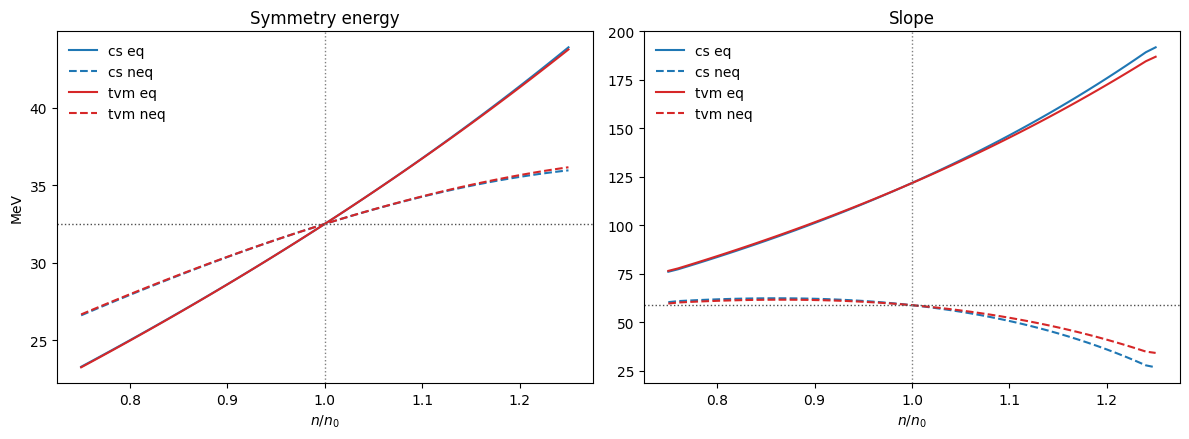

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
style = {
    ("cs", "eq"): {"color": "tab:blue", "ls": "-"},
    ("cs", "neq"): {"color": "tab:blue", "ls": "--"},
    ("tvm", "eq"): {"color": "tab:red", "ls": "-"},
    ("tvm", "neq"): {"color": "tab:red", "ls": "--"},
}

for row in fit_df.itertuples(index=False):
    params = {"an": row.an, "bn": row.bn, "apn": row.apn, "bpn": row.bpn}
    s_vals, l_vals = symmetry_curves(row.model, params, density_grid)
    x = density_grid / rho0
    label = f"{row.model} {row.branch}"
    axes[0].plot(x, s_vals, label=label, **style[(row.model, row.branch)])
    axes[1].plot(x, l_vals, label=label, **style[(row.model, row.branch)])

axes[0].axhline(TARGET_S0, color="0.3", lw=1.0, ls=":")
axes[1].axhline(TARGET_L0, color="0.3", lw=1.0, ls=":")
axes[0].axvline(1.0, color="0.5", lw=1.0, ls=":")
axes[1].axvline(1.0, color="0.5", lw=1.0, ls=":")

axes[0].set_title("Symmetry energy")
axes[1].set_title("Slope")
axes[0].set_ylabel("MeV")
axes[0].set_xlabel(r"$n / n_0$")
axes[1].set_xlabel(r"$n / n_0$")
axes[0].legend(frameon=False)
axes[1].legend(frameon=False)
plt.tight_layout()


## Notes

- The notebook is focused on the hadronic parameter extraction step only.
- The fitted values are close to the hard-coded numbers already used in `QM-isos-4Models.ipynb` and `QM_assym_isos-TVM.py`.
- If you want to chain this directly to the symmetric workflow notebook, replace `symmetric_baselines` with the `a_bar, b_bar` values you prefer to propagate.


In [8]:
# Convert the fitted asymmetric parameters from natural units to MeV fm^3 and fm^3
HBARC_GEV_FM = 0.1973269804
GEV_NEG3_TO_FM3 = HBARC_GEV_FM ** 3
GEV_NEG2_TO_MEV_FM3 = GEV_TO_MEV * GEV_NEG3_TO_FM3

fit_df_physical = fit_df.copy()
for col in ["an", "apn", "delta_a"]:
    fit_df_physical[f"{col}_MeV_fm3"] = fit_df_physical[col] * GEV_NEG2_TO_MEV_FM3
for col in ["bn", "bpn", "delta_b"]:
    fit_df_physical[f"{col}_fm3"] = fit_df_physical[col] * GEV_NEG3_TO_FM3

fit_df_physical["a_bar_MeV_fm3"] = 0.5 * (fit_df_physical["an_MeV_fm3"] + fit_df_physical["apn_MeV_fm3"])
fit_df_physical["b_bar_fm3"] = 0.5 * (fit_df_physical["bn_fm3"] + fit_df_physical["bpn_fm3"])

display(
    fit_df_physical[
        [
            "model", "branch",
            "an_MeV_fm3", "bn_fm3",
            "apn_MeV_fm3", "bpn_fm3",
            "a_bar_MeV_fm3", "b_bar_fm3",
            "S0", "L0",
        ]
    ]
    .rename(columns={
        "an_MeV_fm3": "an [MeV fm^3]",
        "bn_fm3": "bn [fm^3]",
        "apn_MeV_fm3": "apn [MeV fm^3]",
        "bpn_fm3": "bpn [fm^3]",
        "a_bar_MeV_fm3": "a_bar [MeV fm^3]",
        "b_bar_fm3": "b_bar [fm^3]",
    })
    .round({
        "an [MeV fm^3]": 4,
        "bn [fm^3]": 4,
        "apn [MeV fm^3]": 4,
        "bpn [fm^3]": 4,
        "a_bar [MeV fm^3]": 4,
        "b_bar [fm^3]": 4,
        "S0": 4,
        "L0": 4,
    })
)


,model,branch,an [MeV fm^3],bn [fm^3],apn [MeV fm^3],bpn [fm^3],a_bar [MeV fm^3],b_bar [fm^3],S0,L0
0,cs,eq,285.1364,4.4501,410.4514,4.4501,347.7939,4.4501,32.5,121.911
1,cs,neq,205.4810,2.9703,490.1068,5.9298,347.7939,4.4501,32.5,58.900
2,tvm,eq,288.2397,4.3034,411.3435,4.3034,349.7916,4.3034,32.5,121.834
3,tvm,neq,204.2878,2.8142,495.2954,5.7925,349.7916,4.3034,32.5,58.900
